E:\Anaconda\Lib\site-packages\numpy\core\_methods.py:49: RuntimeWarning: invalid value encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)


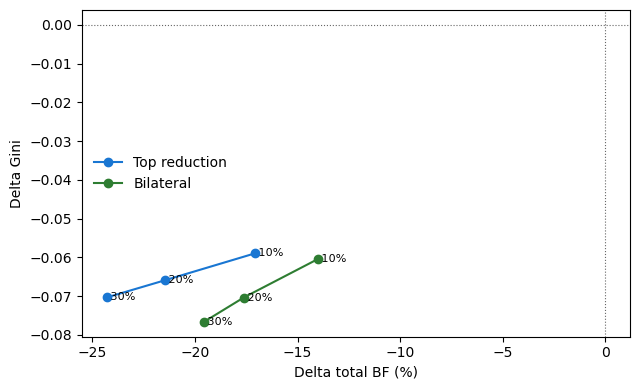

Generated 6 intervention scenarios + BASE.
BASE Gini = 0.5696, total BF = 6.5678e-02
Outputs saved to: .\output\scenario_analysis


In [1]:
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Scenario analysis for the 2023 consumption-based biodiversity footprint.
# Run notebook 1 first, then adjust these paths if needed.
ACC_OUT = r'.\1_Biodiversity_footprint_accounting\output'
HOU_DIR = r'E:\phdstudy\BiodiversityPHD-2ndpaper\household_expenditure'
OUT_DIR = r'.\output\scenario_analysis'
os.makedirs(OUT_DIR, exist_ok=True)

G, S, N = 164, 120, 201   # countries, sectors, income bins
M = G * N
N_DEC = 10

# Load footprint, expenditure, and population data.
fp_income = np.load(os.path.join(ACC_OUT, 'footprint_income_2023.npy'))
with open(os.path.join(ACC_OUT, 'country_order_2023.txt'), encoding='utf-8') as fh:
    country_names = fh.read().splitlines()

target = np.load(os.path.join(HOU_DIR, 'Target_2023.npz'))['Target'].astype(float)
if target.shape != (G * S, M):
    raise ValueError(f'Unexpected Target shape: {target.shape}')

mapping = pd.read_csv(os.path.join(HOU_DIR, 'GLORIA_Country_Mapping.csv'))
pop_raw = pd.read_csv(os.path.join(HOU_DIR, 'Population_by_IncomeGroup.csv'), index_col=0)
pop = np.zeros((G, N))
for gi in range(G):
    for _, row in mapping[mapping['GLORIA_Index'] == gi + 1].iterrows():
        iso3 = row['Population_ISO3']
        if pd.notna(iso3) and iso3 != 'Not in Population' and iso3 in pop_raw.columns:
            pop[gi] += pop_raw[iso3].values[:N]

pop_flat = pop.ravel()
fp_base_total = fp_income.ravel()
exp_total = target.sum(axis=0)
keep = (pop_flat > 0) & (exp_total > 0) & np.isfinite(fp_base_total)
idx = np.where(keep)[0]

e_base = np.zeros(M)
bf_base = np.zeros(M)
m_base = np.zeros(M)
e_base[keep] = exp_total[keep] / pop_flat[keep]
bf_base[keep] = fp_base_total[keep] / pop_flat[keep]
m_base[keep] = np.divide(bf_base[keep], e_base[keep], out=np.zeros(keep.sum()), where=e_base[keep] > 0)

def gini_lorenz(x, w):
    m = np.isfinite(x) & np.isfinite(w) & (w > 0) & (x >= 0)
    x, w = x[m], w[m]
    if x.size == 0:
        return np.nan
    order = np.argsort(x)
    x, w = x[order], w[order]
    total_w = w.sum()
    total_xw = (x * w).sum()
    if total_xw <= 0:
        return np.nan
    lx = np.concatenate([[0.0], np.cumsum(w) / total_w])
    ly = np.concatenate([[0.0], np.cumsum(x * w) / total_xw])
    return float(1 - 2 * np.trapz(ly, lx))

def theil_t(x, w):
    m = np.isfinite(x) & np.isfinite(w) & (w > 0) & (x > 0)
    x, w = x[m], w[m]
    if x.size == 0:
        return np.nan
    w = w / w.sum()
    mean_x = (w * x).sum()
    return float((w * (x / mean_x) * np.log(x / mean_x)).sum())

def scenario_stats(bf_pc, pop_w, label):
    ok = np.isfinite(bf_pc) & np.isfinite(pop_w) & (pop_w > 0)
    x, w = bf_pc[ok], pop_w[ok]
    total = float((x * w).sum())
    order = np.argsort(x)
    xs, ws = x[order], w[order]
    fp = xs * ws
    cw_pop = np.cumsum(ws) / ws.sum()
    return {
        'scenario': label,
        'total_BF': total,
        'Gini': gini_lorenz(x, w),
        'Theil': theil_t(x, w),
        'bot50_share': float(fp[cw_pop <= 0.5].sum() / fp.sum()),
        'top10_share': float(fp[cw_pop > 0.9].sum() / fp.sum()),
        'top20_share': float(fp[cw_pop > 0.8].sum() / fp.sum()),
        'mean_percap': float(total / w.sum()),
    }

def footprint_pc(e_new):
    bf = np.zeros(M)
    bf[keep] = e_new[keep] * m_base[keep]
    return bf

# Build global expenditure deciles with split boundary units.
e_valid = e_base[idx]
pop_valid = pop_flat[idx]
order = np.argsort(e_valid, kind='mergesort')
idx_sorted = idx[order]
pop_sorted = pop_valid[order]
target_pop = pop_sorted.sum() / N_DEC
dec_sorted = np.empty(len(idx_sorted), dtype=int)
border_cells = {}
dec_i = 0
remaining = target_pop

for i, flat_i in enumerate(idx_sorted):
    left = float(pop_sorted[i])
    parts = {}
    while left > 0 and dec_i < N_DEC:
        take = min(left, remaining)
        frac = take / pop_sorted[i]
        parts[dec_i] = parts.get(dec_i, 0.0) + frac
        left -= take
        remaining -= take
        if remaining <= target_pop * 1e-10:
            dec_i += 1
            remaining = target_pop
    if dec_i >= N_DEC:
        dec_i = N_DEC - 1
    dec_sorted[i] = max(parts, key=parts.get)
    if len(parts) > 1:
        border_cells[int(flat_i)] = parts

dec_valid = np.empty(len(idx), dtype=int)
dec_valid[order] = dec_sorted
dec_full = -np.ones(M, dtype=int)
dec_full[idx] = dec_valid
dec_members = {d: idx[dec_valid == d] for d in range(N_DEC)}
dec_e_min = {d: e_base[dec_members[d]].min() for d in range(N_DEC)}
dec_e_max = {d: e_base[dec_members[d]].max() for d in range(N_DEC)}

# Six scale-only scenarios used in the manuscript.
scenarios = {'BASE': bf_base.copy()}
scenario_plan = [('T', 10), ('T', 20), ('T', 30), ('W', 10), ('W', 20), ('W', 30)]

for direction, level in scenario_plan:
    n_dec = level // 10
    top_decs = list(range(N_DEC - n_dec, N_DEC))
    bot_decs = list(range(n_dec))
    e_new = e_base.copy()

    for d in top_decs:
        mem = dec_members[d]
        e_new[mem] = np.minimum(e_base[mem], dec_e_min[d])
    if direction == 'W':
        for d in bot_decs:
            mem = dec_members[d]
            e_new[mem] = np.maximum(e_base[mem], dec_e_max[d])

    if border_cells:
        top_set = set(top_decs)
        bot_set = set(bot_decs) if direction == 'W' else set()
        for flat_i, parts in border_cells.items():
            val = 0.0
            for d, frac in parts.items():
                if d in top_set:
                    val += frac * min(e_base[flat_i], dec_e_min[d])
                elif d in bot_set:
                    val += frac * max(e_base[flat_i], dec_e_max[d])
                else:
                    val += frac * e_base[flat_i]
            e_new[flat_i] = val

    name = f'S_{direction}{level:02d}_e'
    scenarios[name] = footprint_pc(e_new)

# Export results.
rows = [scenario_stats(bf[idx], pop_flat[idx], name) for name, bf in scenarios.items()]
summary = pd.DataFrame(rows)
base = summary.loc[summary['scenario'] == 'BASE'].iloc[0]
summary['dGini'] = summary['Gini'] - base['Gini']
summary['dTheil'] = summary['Theil'] - base['Theil']
summary['BF_pct_change'] = (summary['total_BF'] - base['total_BF']) / base['total_BF'] * 100
summary['mean_pct_change'] = (summary['mean_percap'] - base['mean_percap']) / base['mean_percap'] * 100

decile_rows = []
for d in range(N_DEC):
    mem = dec_members[d]
    pop_d = float(pop_flat[mem].sum())
    row = {'decile': d + 1, 'n_groups': int(mem.size), 'population': pop_d,
           'e_min': dec_e_min[d], 'e_max': dec_e_max[d]}
    for name, bf in scenarios.items():
        total = float((bf[mem] * pop_flat[mem]).sum())
        row[f'BF_total_{name}'] = total
        row[f'BF_percap_{name}'] = total / pop_d if pop_d > 0 else np.nan
    decile_rows.append(row)
decile = pd.DataFrame(decile_rows)

# Manuscript share indicators are based on global expenditure deciles.
for name in scenarios:
    total = float(decile[f'BF_total_{name}'].sum())
    sel = summary['scenario'] == name
    summary.loc[sel, 'bot50_share'] = float(decile.loc[decile['decile'] <= 5, f'BF_total_{name}'].sum() / total)
    summary.loc[sel, 'top10_share'] = float(decile.loc[decile['decile'] == 10, f'BF_total_{name}'].sum() / total)
    summary.loc[sel, 'top20_share'] = float(decile.loc[decile['decile'] >= 9, f'BF_total_{name}'].sum() / total)

long = pd.DataFrame({
    'Country_ID': np.repeat(np.arange(1, G + 1), N)[idx],
    'Country': np.array(country_names)[np.repeat(np.arange(G), N)[idx]],
    'BinIndex': np.tile(np.arange(N), G)[idx],
    'Decile': dec_full[idx] + 1,
    'Population': pop_flat[idx],
    'e_percap': e_base[idx],
})
for name, bf in scenarios.items():
    long[f'BF_percap_{name}'] = bf[idx]

summary.to_csv(os.path.join(OUT_DIR, 'scenario_summary_2023.csv'), index=False)
decile.to_csv(os.path.join(OUT_DIR, 'scenario_decile_2023.csv'), index=False)
long.to_csv(os.path.join(OUT_DIR, 'scenario_footprint_long_2023.csv'), index=False)
with pd.ExcelWriter(os.path.join(OUT_DIR, 'scenario_results_2023.xlsx'), engine='openpyxl') as w:
    summary.to_excel(w, sheet_name='Summary', index=False)
    decile.to_excel(w, sheet_name='Decile', index=False)

# Quick diagnostic plot.
fig, ax = plt.subplots(figsize=(6.5, 4))
plot_df = summary.set_index('scenario')
levels = [10, 20, 30]
for direction, color in [('T', '#1976D2'), ('W', '#2E7D32')]:
    names = [f'S_{direction}{lv:02d}_e' for lv in levels]
    sub = plot_df.reindex(names)
    ax.plot(sub['BF_pct_change'], sub['dGini'], color=color, marker='o', label={'T': 'Top reduction', 'W': 'Bilateral'}[direction])
    for lv, x, y in zip(levels, sub['BF_pct_change'], sub['dGini']):
        ax.text(x, y, f' {lv}%', fontsize=8, va='center')
ax.axhline(0, color='0.4', lw=0.8, ls=':')
ax.axvline(0, color='0.4', lw=0.8, ls=':')
ax.set_xlabel('Delta total BF (%)')
ax.set_ylabel('Delta Gini')
ax.legend(frameon=False)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'scenario_6_tradeoff_2023.png'), dpi=300, bbox_inches='tight')
plt.show()

print(f'Generated {len(scenarios) - 1} intervention scenarios + BASE.')
print(f'BASE Gini = {base.Gini:.4f}, total BF = {base.total_BF:.4e}')
print(f'Outputs saved to: {OUT_DIR}')